In [5]:
# ============================================================
# Function F8 — Week 04 Bayesian Optimisation Loop
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# Goal: MAXIMISE
# ============================================================

# =========================
# Imports (all at top)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")  # keep notebook output clean

In [6]:
# =========================
# 0) Config
# =========================
INPUTS_PATH = "data/F8/initial_inputs.npy"
OUTPUTS_PATH = "data/F8/initial_outputs.npy"

SEED = 0
BOUNDS_LOW = 0.0
BOUNDS_HIGH = 1.0

# Acquisition (UCB)
KAPPA = 1.2  # exploration weight (reduce slowly over weeks)

# Candidate generation sizes
N_GLOBAL = 20000
N_LOCAL = 8000
N_BIASED = 8000

# Local sampling radius
LOCAL_SIGMA = 0.08

# De-duplication precision (avoid re-submitting identical points)
DEDUP_DECIMALS = 6

In [7]:
# =========================
# 1) Load
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 8, f"Expected X shape (n, 8), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,), got {y.shape}"

n = X.shape[0]
best_idx = int(np.argmax(y))
best_x_obs = X[best_idx].copy()
best_y_obs = float(y[best_idx])

print(f"Loaded n={n} observations")
print(f"Best observed y={best_y_obs:.6f} at index={best_idx}")
print("Best observed x:", np.array2string(best_x_obs, precision=6, separator=", "))

Loaded n=42 observations
Best observed y=9.802107 at index=41
Best observed x: [0.231868, 0.356115, 0.159692, 0.196372, 0.938094, 0.792984, 0.113027,
 0.830933]


In [8]:
# =========================
# 2) Surrogate (GP + RF + GBM ensemble)
# =========================
# ---- GP (scaled inputs for numerical stability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=SEED
)
gp.fit(X_scaled, y)

# ---- Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=1
)
rf.fit(X, y)

# ---- GBM ensemble (multiple seeds)
def fit_gbm(seed: int) -> GradientBoostingRegressor:
    m = GradientBoostingRegressor(
        random_state=seed,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8
    )
    m.fit(X, y)
    return m

gbm_seeds = [0, 1, 2, 3, 4]
gbm_list = [fit_gbm(s) for s in gbm_seeds]


def ensemble_predict(Xcand: np.ndarray):
    """
    Returns:
      mu (n,), sigma (n,) using:
        - GP mean/std
        - RF mean/std across trees
        - GBM mean/std across ensemble members
      Combined uncertainty = mean(within-model variances) + between-model disagreement
    """
    # GP
    gp_mu, gp_std = gp.predict(scaler.transform(Xcand), return_std=True)

    # RF tree dispersion
    rf_tree_preds = np.stack([t.predict(Xcand) for t in rf.estimators_], axis=0)
    rf_mu = rf_tree_preds.mean(axis=0)
    rf_std = rf_tree_preds.std(axis=0)

    # GBM ensemble dispersion
    gbm_preds = np.stack([m.predict(Xcand) for m in gbm_list], axis=0)
    gbm_mu = gbm_preds.mean(axis=0)
    gbm_std = gbm_preds.std(axis=0)

    # Ensemble mean
    mu = (gp_mu + rf_mu + gbm_mu) / 3.0

    # Conservative uncertainty: within-model + between-model disagreement
    within = (gp_std**2 + rf_std**2 + gbm_std**2) / 3.0
    between = np.var(np.stack([gp_mu, rf_mu, gbm_mu], axis=0), axis=0)
    sigma = np.sqrt(within + between)

    return mu, sigma


# Quick in-sample health check (version-agnostic RMSE)
mu_train, sig_train = ensemble_predict(X)
r2 = r2_score(y, mu_train)
rmse = np.sqrt(mean_squared_error(y, mu_train))  # <-- FIX: no squared=False

print(f"Surrogate sanity check (in-sample): R2={r2:.4f}, RMSE={rmse:.4f}")


Surrogate sanity check (in-sample): R2=0.9965, RMSE=0.0583


In [9]:
# =========================
# 3) Acquisition (UCB) + candidate generation
# =========================
rng = np.random.default_rng(SEED)

rf_importance = rf.feature_importances_
top_idx = np.argsort(rf_importance)[::-1][:3]  # most influential dims (data-driven)

def generate_candidates():
    # A) Global exploration
    global_c = rng.random((N_GLOBAL, 8))

    # B) Local exploitation around best observed
    local = best_x_obs + rng.normal(0.0, LOCAL_SIGMA, size=(N_LOCAL, 8))
    local = np.clip(local, BOUNDS_LOW, BOUNDS_HIGH)

    # C) Biased sampling: push top dims higher (data-driven),
    # while keeping other dims partly near current best region
    biased = rng.random((N_BIASED, 8))

    for j in top_idx:
        if j == 0:
            # For x1: sample around best +/- a bit
            biased[:, j] = np.clip(best_x_obs[j] + rng.normal(0, 0.15, size=N_BIASED), 0, 1)
        else:
            # For other top dims: bias toward upper half
            biased[:, j] = 0.6 + 0.4 * rng.random(N_BIASED)

    # keep many non-top dims near best (helps refine promising basin)
    for j in range(8):
        if j not in top_idx:
            mask = rng.random(N_BIASED) < 0.5
            biased[mask, j] = np.clip(best_x_obs[j] + rng.normal(0, 0.12, size=mask.sum()), 0, 1)

    return np.vstack([global_c, local, biased])

C = generate_candidates()
mu_c, sig_c = ensemble_predict(C)

ucb = mu_c + KAPPA * sig_c

# De-duplicate against existing points
X_round = np.round(X, DEDUP_DECIMALS)
C_round = np.round(C, DEDUP_DECIMALS)
existing = {tuple(row) for row in X_round}
is_new = np.array([tuple(row) not in existing for row in C_round], dtype=bool)

ucb_masked = ucb.copy()
ucb_masked[~is_new] = -np.inf

best_c_idx = int(np.argmax(ucb_masked))
x_next = C[best_c_idx]
mu_next = float(mu_c[best_c_idx])
sig_next = float(sig_c[best_c_idx])
ucb_next = float(ucb_masked[best_c_idx])

print("\nSelected next point (max UCB):")
print("x_next =", np.array2string(x_next, precision=6, separator=", "))
print(f"pred_mu={mu_next:.6f}, pred_sigma={sig_next:.6f}, UCB={ucb_next:.6f}")




Selected next point (max UCB):
x_next = [0.201507, 0.280888, 0.150852, 0.061778, 1.      , 0.64205 , 0.138749,
 0.884062]
pred_mu=9.758791, pred_sigma=0.328090, UCB=10.152500


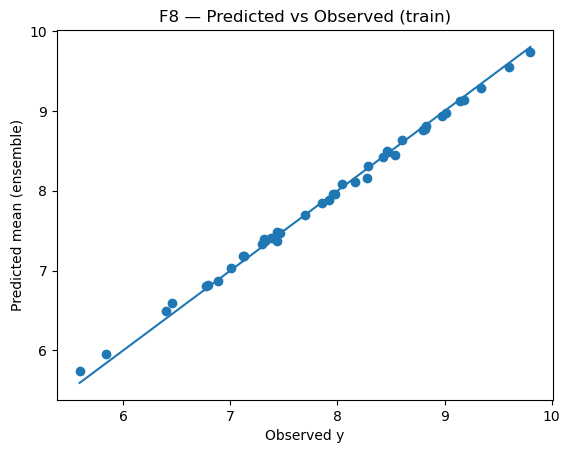

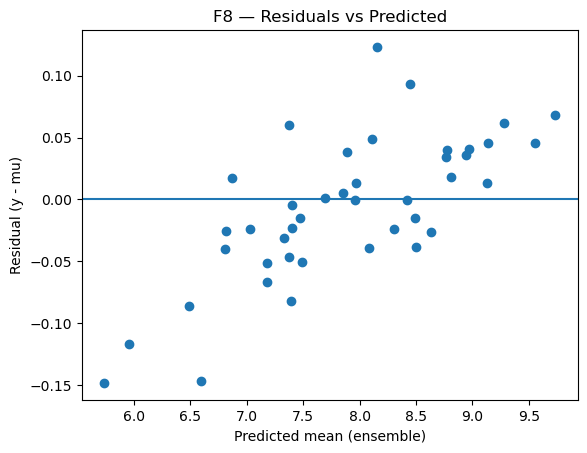

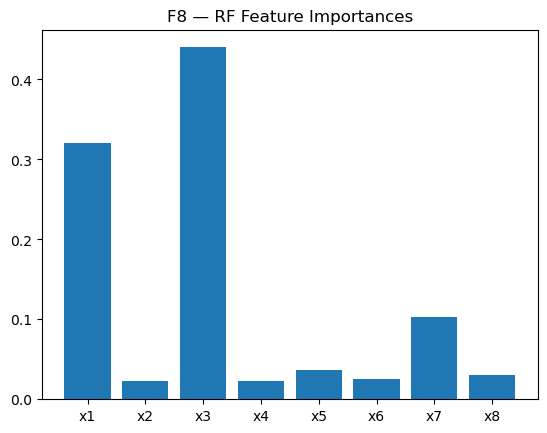

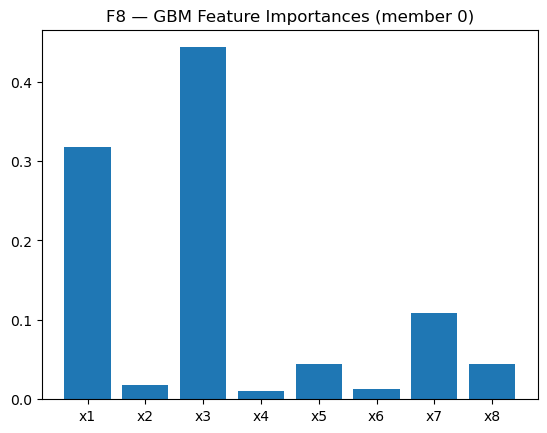

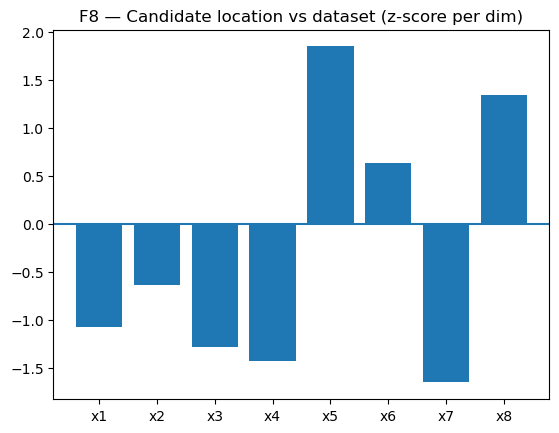

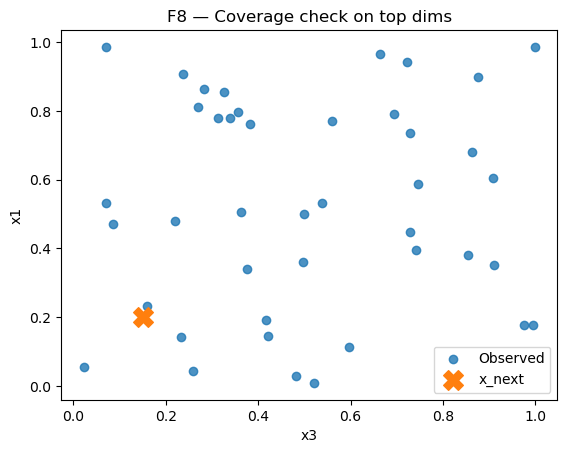

In [10]:
# =========================
# 4) Diagnostics
# =========================
# 4.1 Predicted vs observed
plt.figure()
plt.scatter(y, mu_train)
mn = min(y.min(), mu_train.min())
mx = max(y.max(), mu_train.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed y")
plt.ylabel("Predicted mean (ensemble)")
plt.title("F8 — Predicted vs Observed (train)")
plt.show()

# 4.2 Residuals
resid = y - mu_train
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0)
plt.xlabel("Predicted mean (ensemble)")
plt.ylabel("Residual (y - mu)")
plt.title("F8 — Residuals vs Predicted")
plt.show()

# 4.3 Feature importance (RF + one GBM member)
plt.figure()
plt.bar(np.arange(8), rf_importance)
plt.xticks(np.arange(8), [f"x{i+1}" for i in range(8)])
plt.title("F8 — RF Feature Importances")
plt.show()

gbm_imp = getattr(gbm_list[0], "feature_importances_", None)
if gbm_imp is not None:
    plt.figure()
    plt.bar(np.arange(8), gbm_imp)
    plt.xticks(np.arange(8), [f"x{i+1}" for i in range(8)])
    plt.title("F8 — GBM Feature Importances (member 0)")
    plt.show()

# 4.4 “Not stuck” check: compare x_next to distribution of existing points
means = X.mean(axis=0)
stds = X.std(axis=0) + 1e-12
z = (x_next - means) / stds

plt.figure()
plt.bar(np.arange(8), z)
plt.xticks(np.arange(8), [f"x{i+1}" for i in range(8)])
plt.axhline(0)
plt.title("F8 — Candidate location vs dataset (z-score per dim)")
plt.show()

# 4.5 Coverage check for top-2 important dims
i1, i2 = int(top_idx[0]), int(top_idx[1])
plt.figure()
plt.scatter(X[:, i1], X[:, i2], label="Observed", alpha=0.8)
plt.scatter(x_next[i1], x_next[i2], marker="X", s=200, label="x_next")
plt.xlabel(f"x{i1+1}")
plt.ylabel(f"x{i2+1}")
plt.title("F8 — Coverage check on top dims")
plt.legend()
plt.show()


In [11]:
# =========================
# 5) Output (single line to submit)
# =========================
print("\n=== SUBMIT THIS x_next (single line) ===")
print(" ".join([f"{v:.6f}" for v in x_next]))



=== SUBMIT THIS x_next (single line) ===
0.201507 0.280888 0.150852 0.061778 1.000000 0.642050 0.138749 0.884062
